## Teste inicial do pytorch
https://pytorch.org/hub/nvidia_deeplearningexamples_efficientnet/

In [1]:
import torch
from PIL import Image
import torchvision.transforms as transforms
import numpy as np
import json
import requests
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'Using {device} for inference')

Using cuda for inference


In [2]:
efficientnet = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_efficientnet_b0', pretrained=True)
utils = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_convnets_processing_utils')

efficientnet.eval().to(device)


Downloading: "https://github.com/NVIDIA/DeepLearningExamples/zipball/torchhub" to C:\Users\sthem/.cache\torch\hub\torchhub.zip
Downloading: "https://api.ngc.nvidia.com/v2/models/nvidia/efficientnet_b0_pyt_amp/versions/20.12.0/files/nvidia_efficientnet-b0_210412.pth" to C:\Users\sthem/.cache\torch\hub\checkpoints\nvidia_efficientnet-b0_210412.pth
100%|██████████| 20.5M/20.5M [00:02<00:00, 9.91MB/s]
Using cache found in C:\Users\sthem/.cache\torch\hub\NVIDIA_DeepLearningExamples_torchhub


EfficientNet(
  (stem): Sequential(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (activation): SiLU(inplace=True)
  )
  (layers): Sequential(
    (0): Sequential(
      (block0): MBConvBlock(
        (depsep): Sequential(
          (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (se): SequentialSqueezeAndExcitation(
          (squeeze): Linear(in_features=32, out_features=8, bias=True)
          (expand): Linear(in_features=8, out_features=32, bias=True)
          (activation): SiLU(inplace=True)
          (sigmoid): Sigmoid()
          (mul_a_quantizer): Identity()
          (mul_b_quantizer): Identity()
        )
      

In [3]:
uris = [
    'http://images.cocodataset.org/test-stuff2017/000000024309.jpg',
    'http://images.cocodataset.org/test-stuff2017/000000028117.jpg',
    'http://images.cocodataset.org/test-stuff2017/000000006149.jpg',
    'http://images.cocodataset.org/test-stuff2017/000000004954.jpg',
]

batch = torch.cat(
    [utils.prepare_input_from_uri(uri) for uri in uris]
).to(device)

In [4]:
with torch.no_grad():
    output = torch.nn.functional.softmax(efficientnet(batch), dim=1)
    
results = utils.pick_n_best(predictions=output, n=5)

sample 0: [('laptop, laptop computer', '49.9%'), ('notebook, notebook computer', '36.1%'), ('desk', '3.7%'), ('mouse, computer mouse', '0.5%'), ('space bar', '0.5%')]
sample 1: [('mashed potato', '86.9%'), ('meat loaf, meatloaf', '5.2%'), ('broccoli', '1.9%'), ('plate', '0.3%'), ('guacamole', '0.1%')]
sample 2: [('racket, racquet', '55.8%'), ('tennis ball', '8.4%'), ('ping-pong ball', '2.6%'), ('golf ball', '0.6%'), ('baseball', '0.6%')]
sample 3: [('kelpie', '52.9%'), ('malinois', '4.1%'), ('groenendael', '3.0%'), ('schipperke', '3.0%'), ('Scottish deerhound, deerhound', '2.6%')]


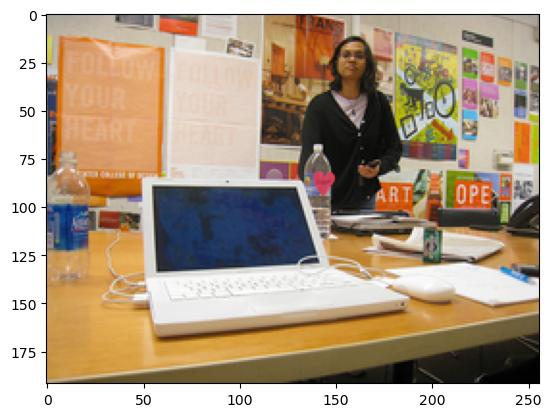

[('laptop, laptop computer', '49.9%'), ('notebook, notebook computer', '36.1%'), ('desk', '3.7%'), ('mouse, computer mouse', '0.5%'), ('space bar', '0.5%')]


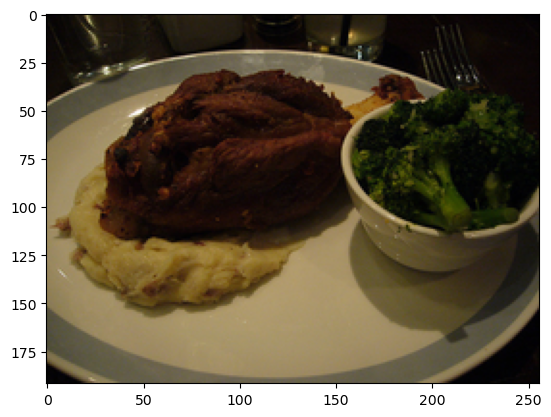

[('mashed potato', '86.9%'), ('meat loaf, meatloaf', '5.2%'), ('broccoli', '1.9%'), ('plate', '0.3%'), ('guacamole', '0.1%')]


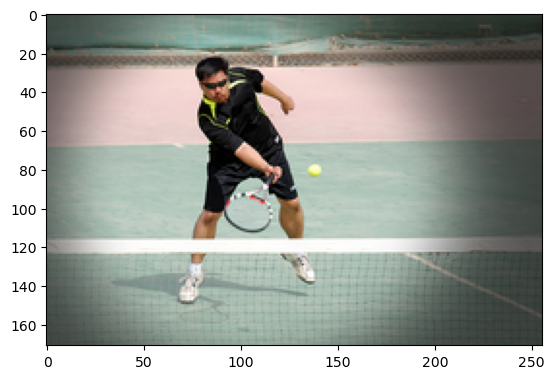

[('racket, racquet', '55.8%'), ('tennis ball', '8.4%'), ('ping-pong ball', '2.6%'), ('golf ball', '0.6%'), ('baseball', '0.6%')]


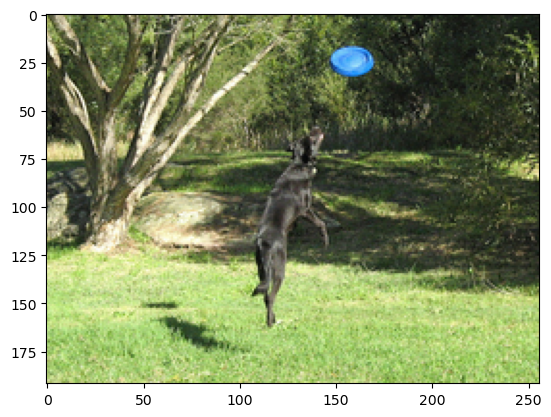

[('kelpie', '52.9%'), ('malinois', '4.1%'), ('groenendael', '3.0%'), ('schipperke', '3.0%'), ('Scottish deerhound, deerhound', '2.6%')]


In [6]:
for uri, result in zip(uris, results):
    img = Image.open(requests.get(uri, stream=True).raw)
    img.thumbnail((256,256), Image.Resampling.LANCZOS)
    plt.imshow(img)
    plt.show()
    print(result)

## vendo qual o tamanho das minhas images da alemanha

In [ ]:
from PIL import Image
import requests

In [9]:
img = Image.open(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\imagens-alemanha\img_dir\train\2022_03_21_11_02_58_05.bmp")
print(img.size)

(2048, 1088)


In [13]:
img.show() 

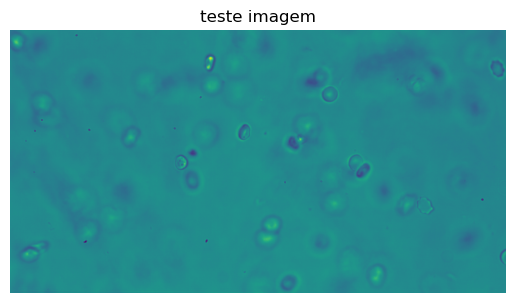

In [14]:
plt.imshow(img)
plt.axis('off')  # remove os eixos
plt.title("teste imagem")
plt.show()

### Criando uma divisão de teste e validação, só para testes rápidos

In [21]:
import os
import shutil
import random
from pathlib import Path

original_dir = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\cell_images'
base_dir = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\cell_images_split'

train_ratio = 0.8

random.seed(42)

for split in ['train', 'val']:
    for category in ['Parasitized', 'Uninfected']:
        Path(os.path.join(base_dir, split, category)).mkdir(parents=True, exist_ok=True)

for category in ['Parasitized', 'Uninfected']:
    src_folder = os.path.join(original_dir, category)
    all_files = os.listdir(src_folder)
    random.shuffle(all_files)

    split_index = int(len(all_files) * train_ratio)
    train_files = all_files[:split_index]
    val_files = all_files[split_index:]

    
    for filename in train_files:
        src = os.path.join(src_folder, filename)
        dst = os.path.join(base_dir, 'train', category, filename)
        shutil.copyfile(src, dst)
        
    for filename in val_files:
        src = os.path.join(src_folder, filename)
        dst = os.path.join(base_dir, 'val', category, filename)
        shutil.copyfile(src, dst)

print("Separação concluída!")


Separação concluída!


## Testando no dataset de malária

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import os



Fazendo a separação e uso das imagens. Mais pra cima no código fiz a parte de separar na pasta em si, só pra fim de ficar mais rápidos os testes (nesse nosso caso, as classes não são desbalanceadas, mas no dataset da Alemanha tenho certeza de que vão ser.)

In [26]:
data_dir = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\cell_images_split'

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=32,
                                              shuffle=True, num_workers=4)
               for x in ['train', 'val']}

class_names = image_datasets['train'].classes
num_classes = 2

Agora, carregar o modelo pré treinado aqui. Peguei o B0 só pra teste e podemos pensar em usar a b4 depois, acho que pode ser viável pra comparar com as redes mais parrudas que estamos usando.

In [24]:
model = models.efficientnet_b0(pretrained=True)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\sthem/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 56.3MB/s]


Só colocando aqui a substituição da última camada por uma que tenha as nossas classes - sim e não pra malária

In [27]:
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, num_classes)



Função de perda e tbm o otimizador

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



Treinando o modelo em 10 epocas, sem muitas métricas ainda - pra entender como ele funciona.

In [29]:
num_epochs = 10
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    print(f'Época {epoch+1}/{num_epochs}')
    print('-' * 10)

    # Cada época tem uma fase de treinamento e validação
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # Define o modelo para treinamento
        else:
            model.eval()   # Define o modelo para avaliação

        running_loss = 0.0
        running_corrects = 0

        # Itera sobre os dados
        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Zera os gradientes
            optimizer.zero_grad()

            # Forward
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                # Backward + otimização apenas na fase de treinamento
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            # Estatísticas
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = running_corrects.double() / len(image_datasets[phase])

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')



Época 1/10
----------
train Loss: 0.3259 Acc: 0.8632
val Loss: 0.1384 Acc: 0.9492
Época 2/10
----------
train Loss: 0.2878 Acc: 0.8754
val Loss: 0.1149 Acc: 0.9588
Época 3/10
----------
train Loss: 0.2715 Acc: 0.8832
val Loss: 0.1158 Acc: 0.9537
Época 4/10
----------
train Loss: 0.2727 Acc: 0.8821
val Loss: 0.1404 Acc: 0.9534
Época 5/10
----------
train Loss: 0.2658 Acc: 0.8855
val Loss: 0.1030 Acc: 0.9621
Época 6/10
----------
train Loss: 0.2612 Acc: 0.8885
val Loss: 0.1080 Acc: 0.9630
Época 7/10
----------
train Loss: 0.2566 Acc: 0.8884
val Loss: 0.1046 Acc: 0.9632
Época 8/10
----------
train Loss: 0.2541 Acc: 0.8918
val Loss: 0.1088 Acc: 0.9626
Época 9/10
----------
train Loss: 0.2471 Acc: 0.8939
val Loss: 0.1017 Acc: 0.9630
Época 10/10
----------
train Loss: 0.2513 Acc: 0.8908
val Loss: 0.1293 Acc: 0.9507


Pra salvar o modelinho em pth

Estava pensando se faz sentido pensar em como adaptar ele pra uso em um celular - tipo tensorflow lite (seria um bom tipo de IC pra Amanda)

In [30]:
torch.save(model.state_dict(), 'modelo_efficientnetb0.pth')




ver sobre esse tutorial depois:
https://debuggercafe.com/transfer-learning-using-efficientnet-pytorch/

https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html